In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# the output path for the csv file
df = pd.read_csv('./ines_pasture_cp_bm_2023.csv', parse_dates=['date'])

In [41]:
df_sub = df.copy()

In [42]:
df_sub['Period'] = np.nan

In [43]:
df_sub.loc[(df_sub['Pasture'] == '6W') &
 ~((df_sub['date'].isin(pd.date_range('5-16-2023', '6-22-2023'))) |
  (df_sub['date'].isin(pd.date_range('7-18-2023', '7-31-2023')))), ['Biomass_kg_ha', 'CP']] = np.nan
df_sub.loc[(df_sub['Pasture'] == '13W') &
 (~df_sub['date'].isin(pd.date_range('6-22-2023', '7-18-2023'))), ['Biomass_kg_ha', 'CP']] = np.nan

df_sub.loc[(df_sub['Pasture'] == '6W') &
(df_sub['date'].isin(pd.date_range('5-16-2023', '6-22-2023'))), 'Period'] = '1'
df_sub.loc[(df_sub['Pasture'] == '6W') &
(df_sub['date'].isin(pd.date_range('7-18-2023', '7-31-2023'))), 'Period'] = '3'

df_sub.loc[(df_sub['Pasture'] == '13W') &
(df_sub['date'].isin(pd.date_range('6-22-2023', '7-18-2023'))), 'Period'] = '2'


In [44]:
df_sub['CP_orig'] = df['CP']
df_sub['Biomass_kg_ha_orig'] = df['Biomass_kg_ha']

In [45]:
df_sub[df_sub['CP'].notnull()]

,date,Pasture,BARE,NONVEG,GREEN,SD,LITT,Biomass_kg_ha,Biomass_SE,NDVI,CP,DRYVEG,Year,Period,CP_orig,Biomass_kg_ha_orig
271,2023-05-16,6W,0.290817,0.552454,0.235753,0.211793,0.261636,522.10430,134.43985,0.291684,11.039038,0.473430,2023,1,11.039038,522.10430
273,2023-05-17,6W,0.287332,0.545779,0.249623,0.204599,0.258447,540.70090,134.46300,0.297887,11.157065,0.463045,2023,1,11.157065,540.70090
275,2023-05-18,6W,0.283855,0.538974,0.263696,0.197330,0.255119,559.35810,134.47707,0.304159,11.250880,0.452449,2023,1,11.250880,559.35810
277,2023-05-19,6W,0.280406,0.532061,0.277929,0.190010,0.251656,578.03430,134.52464,0.310482,11.307787,0.441665,2023,1,11.307787,578.03430
279,2023-05-20,6W,0.277002,0.525061,0.292277,0.182662,0.248058,596.68726,134.58067,0.316838,11.318496,0.430720,2023,1,11.318496,596.68726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2023-07-27,6W,0.200805,0.222161,0.700699,0.077140,0.021355,1704.85790,144.72221,0.523257,9.385749,0.098496,2023,3,9.385749,1704.85790
417,2023-07-28,6W,0.199419,0.220633,0.700877,0.078490,0.021214,1713.32360,144.95752,0.523524,9.396626,0.099704,2023,3,9.396626,1713.32360
419,2023-07-29,6W,0.198119,0.219290,0.700961,0.079749,0.021170,1720.92460,145.19064,0.523614,9.410415,0.100920,2023,3,9.410415,1720.92460
421,2023-07-30,6W,0.196907,0.218131,0.700926,0.080943,0.021224,1727.61740,145.42163,0.523509,9.424730,0.102167,2023,3,9.424730,1727.61740


In [46]:
df_plot = df_sub[df_sub['date'].isin(pd.date_range('5-1-2023', '9-30-2023'))].copy()

In [47]:
df_plot = pd.melt(df_plot,
        id_vars=['Pasture', 'date', 'Period'],
        value_vars=['CP', 'CP_orig', 'Biomass_kg_ha', 'Biomass_kg_ha_orig'])

In [48]:
df_plot['Type'] = df_plot['variable'].apply(lambda x: 'orig' if 'orig' in x else 'sub')

In [49]:
df_plot = df_plot.reset_index(drop=True)

In [50]:
df_plot[(df_plot['Type'] == 'sub') & df_plot['value'].notnull()]

,Pasture,date,Period,variable,value,Type
31,6W,2023-05-16,1,CP,11.039038,sub
33,6W,2023-05-17,1,CP,11.157065,sub
35,6W,2023-05-18,1,CP,11.250880,sub
37,6W,2023-05-19,1,CP,11.307787,sub
39,6W,2023-05-20,1,CP,11.318496,sub
...,...,...,...,...,...,...
787,6W,2023-07-27,3,Biomass_kg_ha,1704.857900,sub
789,6W,2023-07-28,3,Biomass_kg_ha,1713.323600,sub
791,6W,2023-07-29,3,Biomass_kg_ha,1720.924600,sub
793,6W,2023-07-30,3,Biomass_kg_ha,1727.617400,sub


In [51]:
import re

In [52]:
df_plot['variable'] = df_plot['variable'].apply(lambda x: re.sub('_orig', '', x))

In [53]:
df_plot = pd.pivot(df_plot, index=['Pasture', 'date', 'Period', 'variable'], columns='Type', values='value').reset_index()

In [55]:
#df_plot

In [56]:
df_plot[df_plot['sub'].notnull()]

Type,Pasture,date,Period,variable,orig,sub
104,13W,2023-06-22,2,Biomass_kg_ha,1095.907000,1095.907000
105,13W,2023-06-22,2,CP,10.489310,10.489310
106,13W,2023-06-23,2,Biomass_kg_ha,1110.463500,1110.463500
107,13W,2023-06-23,2,CP,10.504084,10.504084
108,13W,2023-06-24,2,Biomass_kg_ha,1124.964000,1124.964000
...,...,...,...,...,...,...
485,6W,2023-07-29,3,CP,9.410415,9.410415
486,6W,2023-07-30,3,Biomass_kg_ha,1727.617400,1727.617400
487,6W,2023-07-30,3,CP,9.424730,9.424730
488,6W,2023-07-31,3,Biomass_kg_ha,1733.364000,1733.364000


In [57]:
from matplotlib.ticker import MultipleLocator

In [58]:
sns.set(font_scale=1.4)
sns.set_style("ticks")

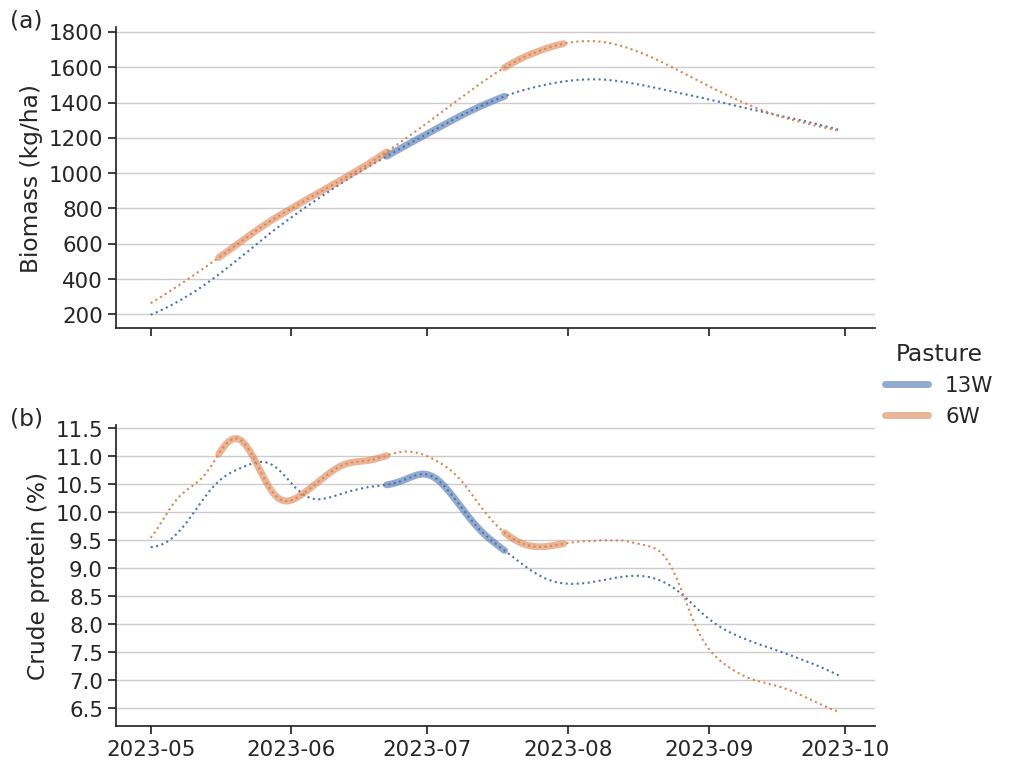

In [61]:
panel_list = ['(a)', '(b)', '(c)', '(d)']
g = sns.FacetGrid(row='variable', hue='Pasture',
                  data=df_plot, aspect=2, height=4, 
                  #hue_order=['17N', '17S-R1', '17S-R2', '17S-R3',
                  #           '19N', '18S-R1/3', '18S-R2/4'],
                  legend_out=True, sharey='row', margin_titles=True)
g.map_dataframe(plt.plot, 'date', 'orig', linestyle='dotted')
g.map_dataframe(plt.plot, 'date', 'sub', linewidth=5, alpha=0.6)
for idx, ax in enumerate(g.axes.flatten()):
    ax.yaxis.grid(True)
    ax.set_xlabel('')
    if idx == 0:
        ax.yaxis.set_major_locator(MultipleLocator(base=200))
        
    else:
        ax.yaxis.set_major_locator(MultipleLocator(base=0.5))
    ax.annotate(panel_list[idx], (-0.14, 1.0), xycoords='axes fraction')
    #ax.set_ylim(ymin=0)
    #ax.legend()
    #ax.tick_params(axis='x', direction='in', length=20, width=2, color='k')
g.axes[0,0].set_ylabel('Biomass (kg/ha)')    
g.axes[1,0].set_ylabel('Crude protein (%)')    
# Remove individual facet titles by setting empty templates
g.set_titles(col_template="", row_template="")
g.add_legend(loc='center right', bbox_to_anchor=(1.1, 0.5))
#g.tick_params(axis='x', direction='in', length=6, width=2, color='k')
plt.tight_layout(w_pad=2, h_pad=3)
plt.savefig('rema_ines_bm_cp_summary_plot.png', dpi=300, bbox_inches='tight')
plt.savefig('rema_ines_bm_cp_summary_plot.pdf', dpi=300, bbox_inches='tight')

In [62]:
df_sub.dropna().groupby(['Pasture', 'Period']).agg({'Biomass_kg_ha': ['mean', 'std', 'min', 'max'],
                               'CP': ['mean', 'std', 'min', 'max'],
                               'date': ['min', 'max']}).round(2).to_csv('./rema_ines_pasture_stats.csv')

In [64]:
df[['date', 'Pasture', 'Biomass_kg_ha', 'CP']].round(2).to_csv('./rema_ines_cp_bm_2023_full.csv', index=False)